# Estimate SRI12 form the observed stream flow data (1912-2000)

First drought events with duration and severity:
       Start        End  Duration_months   Severity   Min_SRI  Year_start
0 1913-08-01 1914-09-01               13  13.351641 -2.324010        1913
1 1941-08-01 1941-11-01                3   0.582380 -1.337741        1941
2 1972-09-01 1973-10-01               13   8.981480 -2.022346        1972
3 1979-09-01 1980-09-01               12   6.032922 -1.626635        1979
4 1980-10-01 1980-11-01                1   0.017405 -1.017405        1980

Annual maximum severity per year (with duration):
   Year  AMS_max_severity  Duration_months_of_max Start_of_max_event  \
0  1913         13.351641                      13         1913-08-01   
1  1941          0.582380                       3         1941-08-01   
2  1972          8.981480                      13         1972-09-01   
3  1979          6.032922                      12         1979-09-01   
4  1980          0.017405                       1         1980-10-01   

  End_of_max_event  Min

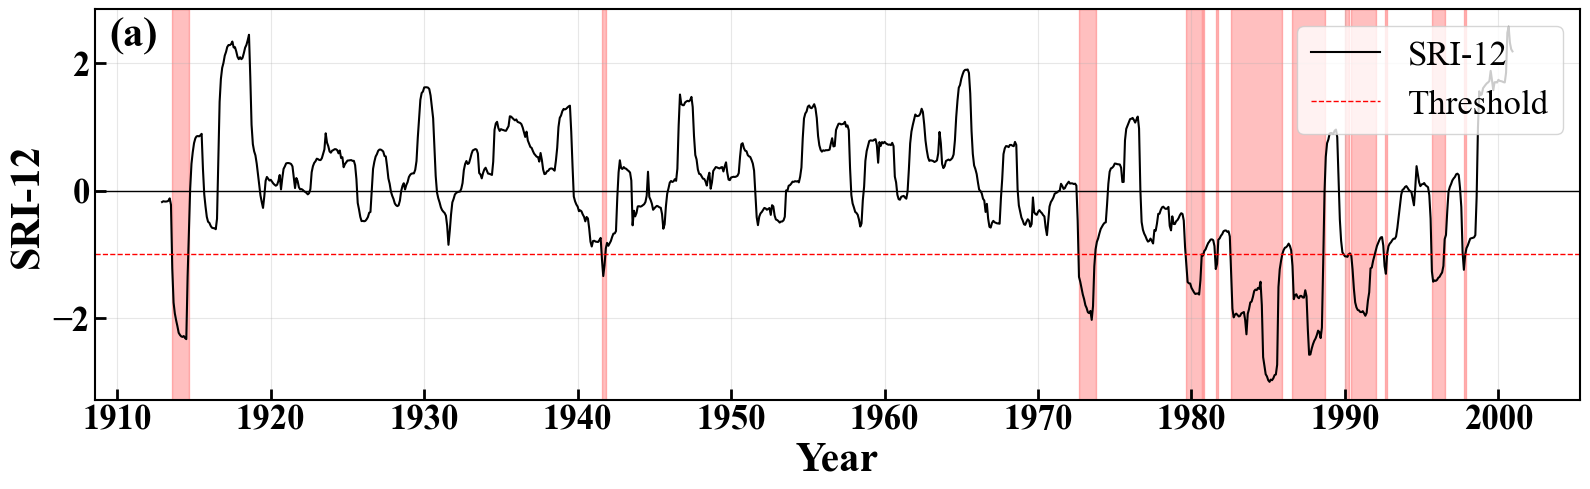

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import os
import matplotlib as mpl

# ==========================================================
# 0) Global style (bold, Nature-like)
# ==========================================================
mpl.rcParams["font.family"]    = "serif"
mpl.rcParams["font.serif"]     = ["Times New Roman", "Times", "DejaVu Serif"]
mpl.rcParams["axes.linewidth"] = 2

# ==========================================================
# 1) Load SRI-12 (Dongola) from your Excel file
# ==========================================================
sri_path = r"\historical observed datat\Dongola_SRI12_gamma.xlsx"    # add your path here

df_sri = pd.read_excel(sri_path, sheet_name=0)

# Detect date column
date_col = None
for c in df_sri.columns:
    if str(c).strip().lower() in ["date", "time", "datetime"]:
        date_col = c
        break
if date_col is None:
    date_col = df_sri.columns[0]  # fallback: first column

# Detect SRI column
sri_col = None
for c in df_sri.columns:
    cl = str(c).strip().lower()
    if "sri12" in cl or cl == "sri" or "sri" in cl:
        sri_col = c
        break
if sri_col is None:
    raise ValueError(f"Could not detect SRI column in {df_sri.columns.tolist()}.")

df_sri[date_col] = pd.to_datetime(df_sri[date_col])
df_sri = df_sri.sort_values(date_col)

series = df_sri.set_index(date_col)[sri_col].astype(float)

# ==========================================================
# 2) Build drought events with Duration & Severity
# ==========================================================
threshold = -1.0  # drought threshold on SRI

events = []
in_drought = False
start = None

for date, val in series.items():
    if val <= threshold:
        if not in_drought:
            in_drought = True
            start = date
    else:
        if in_drought:
            end = date
            events.append({"Start": start, "End": end})
            in_drought = False

if in_drought:
    events.append({"Start": start, "End": series.index[-1]})

drought_df = pd.DataFrame(events)

if not drought_df.empty:
    durations = []
    severities = []
    min_sri_vals = []
    years_start = []

    for _, row in drought_df.iterrows():
        mask = (series.index >= row["Start"]) & (series.index <= row["End"])
        event_vals = series.loc[mask]
        event_vals = event_vals[event_vals <= threshold]

        dur_months = len(event_vals)
        sev = float((threshold - event_vals).sum())
        min_sri = float(event_vals.min())

        durations.append(dur_months)
        severities.append(sev)
        min_sri_vals.append(min_sri)
        years_start.append(row["Start"].year)

    drought_df["Duration_months"] = durations
    drought_df["Severity"] = severities
    drought_df["Min_SRI"] = min_sri_vals
    drought_df["Year_start"] = years_start
else:
    drought_df["Duration_months"] = []
    drought_df["Severity"] = []
    drought_df["Min_SRI"] = []
    drought_df["Year_start"] = []

print("First drought events with duration and severity:")
print(drought_df.head())

# ==========================================================
# 3) Annual maximum severity per year (AMS)
# ==========================================================
if not drought_df.empty:
    tmp = drought_df.sort_values(
        ["Year_start", "Severity", "Duration_months"],
        ascending=[True, False, False]
    )
    best = tmp.drop_duplicates(subset=["Year_start"], keep="first").copy()

    ams = best[["Year_start", "Severity", "Duration_months", "Start", "End", "Min_SRI"]].copy()
    ams = ams.rename(columns={
        "Year_start": "Year",
        "Severity": "AMS_max_severity",
        "Duration_months": "Duration_months_of_max",
        "Start": "Start_of_max_event",
        "End": "End_of_max_event",
        "Min_SRI": "Min_SRI_of_max_event"
    })
else:
    ams = pd.DataFrame(columns=[
        "Year", "AMS_max_severity", "Duration_months_of_max",
        "Start_of_max_event", "End_of_max_event", "Min_SRI_of_max_event"
    ])

print("\nAnnual maximum severity per year (with duration):")
print(ams.head())

# ==========================================================
# 4) Save tables to Excel
# ==========================================================
out_dir = os.path.dirname(sri_path)
out_path = os.path.join(out_dir, "Dongola_SRI12_drought_events_and_AMS.xlsx")

# Close the file if it's already open
try:
    with pd.ExcelWriter(out_path, engine='openpyxl') as w:
        drought_df.to_excel(w, sheet_name="Events", index=False)
        ams.to_excel(w, sheet_name="AMS_severity_duration", index=False)
except PermissionError:
    print("File is currently open. Closing and retrying...")
    out_path = os.path.join(out_dir, "Dongola_SRI12_drought_events_and_AMS_new.xlsx")
    with pd.ExcelWriter(out_path, engine='openpyxl') as w:
        drought_df.to_excel(w, sheet_name="Events", index=False)
        ams.to_excel(w, sheet_name="AMS_severity_duration", index=False)

print("\nSaved events + AMS to:", out_path)

# ==========================================================
# 5) Plot SRI with shaded drought events (single clean figure)
# ==========================================================
fig, ax = plt.subplots(figsize=(16,5))

ax.plot(series.index, series.values, color='black', lw=1.5, label='SRI-12')
ax.axhline(threshold, color='red', linestyle='--', lw=1.0, label='Threshold')

for _, row in drought_df.iterrows():
    ax.axvspan(row["Start"], row["End"], color='red', alpha=0.25)

# Labels and title
ax.set_ylabel("SRI-12", fontsize=30, fontweight="bold")
ax.set_xlabel("Year", fontsize=30, fontweight="bold")


# Tick size and bold numbers
ax.tick_params(axis='both', which='major', labelsize=25, width=2)
for lab in ax.get_xticklabels() + ax.get_yticklabels():
    lab.set_fontweight("bold")
ax.tick_params(axis="both", direction='in' , length=8, width=2)
# Bold outline
for spine in ax.spines.values():
    spine.set_linewidth(1.5)
    spine.set_color("black")

ax.grid(alpha=0.3)
ax.axhline(0, color="black", linewidth=1)

ax.xaxis.set_major_locator(mdates.YearLocator(10))
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
ax.tick_params(axis="both", direction='in' , length=8, width=2)
ax.legend(loc='upper right', fontsize=25)

# Panel label (a)
ax.text(
    0.01, 0.98, "(a)",
    transform=ax.transAxes,
    fontsize=30,
    fontweight="bold",
    va="top",
    ha="left"
)

plt.tight_layout()
plt.show()


# Estimate SRI12 from 6 simulated stream flow

In [ ]:
import os
import numpy as np
import pandas as pd
from scipy.stats import gamma, norm

# ============================================================
# 1) Input files (your models)
# ============================================================
files = {
    "BCC-CSM2-MR (ssp4.5)low"    : r"\future stream flow\BCC-CSM2-MR.xlsx",                           # add your path here
    "CESM2-WACCM(ssp4.5)median"  : r"\future stream flow\CESM2-WACCM.xlsx",                           # add your path here
    "CMCC-CM2-SR5 (ssp 4.5)high" : r"future stream flow\CMCC-CM2-SR5.xlsx",                           # add your path here
    "CanESM5 (ssp8.5)median"     : r"\future stream flow\CanESM5.xlsx",                                 # add your path here
    "INM-CM4-8 (ssp8.5)high"     : r"\doaa drought paper_revision\future stream flow\INM-CM4-8 .xlsx",  # add your path here
    "NorESM2-LM(ssp8.5)low)"     : r"\doaa drought paper_revision\future stream flow\NorESM2-LM.xlsx",  # add your path here 
}

scenario_map = {
    "BCC-CSM2-MR (ssp4.5)low"    : "SSP2-4.5",
    "CESM2-WACCM(ssp4.5)median"  : "SSP2-4.5",
    "CMCC-CM2-SR5 (ssp 4.5)high" : "SSP2-4.5",
    "CanESM5 (ssp8.5)median"     : "SSP5-8.5",
    "INM-CM4-8 (ssp8.5)high"     : "SSP5-8.5",
    "NorESM2-LM(ssp8.5)low)"     : "SSP5-8.5",
}

# ============================================================
# 2) Settings
# ============================================================
START_YEAR = 2025
END_YEAR   = 2100

# If monthly Q is discharge (m3/s): use rolling MEAN (recommended)
# If monthly Q is volume (m3/month): use rolling SUM
AGG_METHOD = "mean"   # "mean" or "sum"

OUT_DIR = r"\future stream flow\SRI12_outputs"                         # add your path here
os.makedirs(OUT_DIR, exist_ok=True)

# ============================================================
# 3) Helpers
# ============================================================
def build_monthly_dates_from_year_rows(df, year_col, q_col):
    """
    Assumes df has one column with 'year' and one column with monthly Q values
    repeated 12 rows per year in order Jan..Dec (or at least consistent order).
    """
    tmp = df[[year_col, q_col]].copy()
    tmp.columns = ["year", "Q"]

    tmp["year"] = pd.to_numeric(tmp["year"], errors="coerce")
    tmp["Q"]    = pd.to_numeric(tmp["Q"], errors="coerce")
    tmp = tmp.dropna(subset=["year", "Q"])
    tmp["year"] = tmp["year"].astype(int)

    # Create month index by row order within each year
    tmp["month"] = tmp.groupby("year").cumcount() + 1
    tmp["month"] = ((tmp["month"] - 1) % 12) + 1

    tmp["date"] = pd.to_datetime(
        dict(year=tmp["year"], month=tmp["month"], day=15),
        errors="coerce"
    )
    tmp = tmp.dropna(subset=["date"]).sort_values("date")
    return tmp

def rolling_12(series, method="mean"):
    if method == "sum":
        return series.rolling(12, min_periods=12).sum()
    return series.rolling(12, min_periods=12).mean()

def sri_from_gamma_by_month(df, value_col="Q12"):
    """
    Compute SRI by fitting Gamma per calendar month to value_col.
    Handles zeros with a mixed distribution approach:
      F(x) = p0 + (1-p0)*GammaCDF(x)
    If Gamma fitting fails for a month, fall back to empirical CDF.
    """
    out = df.copy()
    out["SRI12"] = np.nan

    for m in range(1, 13):
        mask = out["month"] == m
        x = out.loc[mask, value_col].astype(float).values

        # Need enough data points to fit reliably
        x_nonan = x[~np.isnan(x)]
        if len(x_nonan) < 10:
            continue

        # Mixed distribution for zeros (rare for Nile, but safe)
        x_pos = x_nonan[x_nonan > 0]
        p0 = np.mean(x_nonan <= 0)

        # If too few positive values, use empirical only
        use_empirical = (len(x_pos) < 10)

        if not use_empirical:
            try:
                # Gamma fit (force loc=0)
                a, loc, scale = gamma.fit(x_pos, floc=0)

                # Compute CDF for all x (including zeros)
                cdf = np.zeros_like(x_nonan, dtype=float)
                cdf[x_nonan <= 0] = p0  # all non-positive mapped to p0
                cdf[x_nonan > 0]  = p0 + (1 - p0) * gamma.cdf(x_nonan[x_nonan > 0], a, loc=0, scale=scale)

            except Exception:
                use_empirical = True

        if use_empirical:
            # Empirical CDF (Weibull plotting position), month-wise
            ranks = pd.Series(x_nonan).rank(method="average").values
            cdf = ranks / (len(x_nonan) + 1.0)

        # Convert to standard normal; clip to avoid inf
        cdf = np.clip(cdf, 1e-6, 1 - 1e-6)
        sri = norm.ppf(cdf)

        # write back to matching rows (only non-NaN positions)
        idx = out.loc[mask].index
        valid_idx = idx[out.loc[mask, value_col].notna().values]
        out.loc[valid_idx, "SRI12"] = sri

    return out

# ============================================================
# 4) Loop models, compute SRI-12 (2025–2100), export
# ============================================================
all_models_long = []

for model_name, path in files.items():
    df = pd.read_excel(path)
    df.columns = [c.strip() for c in df.columns]

    # Assume first column = year, second column = Q (your current structure)
    year_col = df.columns[0]
    q_col    = df.columns[1]

    tmp = build_monthly_dates_from_year_rows(df, year_col, q_col)

    # Filter to 2025–2100
    tmp = tmp[(tmp["year"] >= START_YEAR) & (tmp["year"] <= END_YEAR)].copy()
    tmp = tmp.sort_values("date")

    if tmp.empty:
        print(f"Skipping {model_name}: no data in {START_YEAR}-{END_YEAR}")
        continue

    # 12-month aggregation
    tmp["Q12"] = rolling_12(tmp["Q"], method=AGG_METHOD)

    # Keep only rows where Q12 exists (after first 11 months)
    tmp = tmp.dropna(subset=["Q12"]).copy()
    tmp["scenario"] = scenario_map.get(model_name, "")
    tmp["model"] = model_name

    # Compute SRI-12 using month-wise gamma standardization
    tmp = sri_from_gamma_by_month(tmp, value_col="Q12")

    # Save per model
    safe = model_name.replace(" ", "_").replace("(", "").replace(")", "").replace("-", "")
    out_xlsx = os.path.join(OUT_DIR, f"SRI12_{safe}_{START_YEAR}_{END_YEAR}.xlsx")
    tmp.to_excel(out_xlsx, index=False)
    print("Saved:", out_xlsx)

    all_models_long.append(tmp)

# Save combined file
if all_models_long:
    df_all = pd.concat(all_models_long, ignore_index=True)
    out_all = os.path.join(OUT_DIR, f"SRI12_ALL_MODELS_{START_YEAR}_{END_YEAR}.xlsx")
    df_all.to_excel(out_all, index=False)
    print("\nSaved combined:", out_all)
else:
    print("\nNo outputs created (check your input files).")


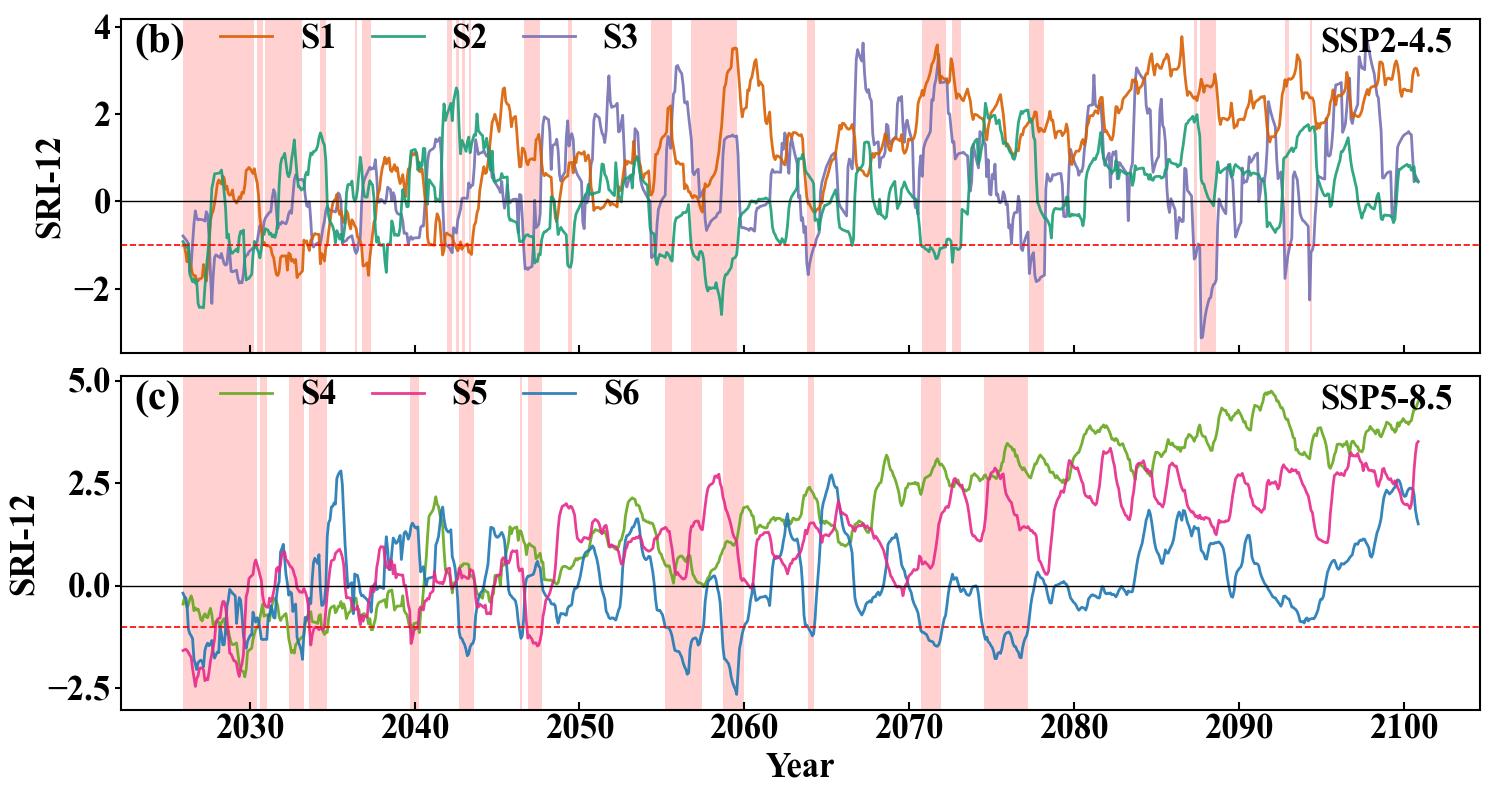

Saved: D:\doaa drought paper_revision\future stream flow\SRI12_outputs\plots_baseline\SRI12_baseline_ANYmodel_shading_thresh_-1p0_Slabels_ordered.png


In [ ]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib as mpl   # ← ADD THIS FIRST

# ADD THESE LINES RIGHT HERE
mpl.rcParams["font.family"] = "serif"
mpl.rcParams["font.serif"] = ["Times New Roman"]

import matplotlib.pyplot as plt
# ------------------------------------------------------------
# INPUT / OUTPUT
# ------------------------------------------------------------
in_path = r"\future stream flow\SRI12_outputs\SRI12_ALL_MODELS_2025_2100_BASE_2025_2054.xlsx"                # add your path here
out_dir = r"\future stream flow\SRI12_outputs\plots_baseline"                                                # add your path here
os.makedirs(out_dir, exist_ok=True)

# ------------------------------------------------------------
# SETTINGS
# ------------------------------------------------------------
SRI_COL = "SRI12_base"
THRESH = -1.0
MIN_DUR = 3

PANEL_LABELS = {"SSP2-4.5": "(b)", "SSP5-8.5": "(c)"}

MODEL_COLORS = {
    "CMCC-CM2-SR5 (ssp 4.5)high": "#1b9e77",
    "CESM2-WACCM(ssp4.5)median":  "#d95f02",
    "BCC-CSM2-MR (ssp4.5)low":    "#7570b3",
    "CanESM5 (ssp8.5)median":     "#66a61e",
    "NorESM2-LM(ssp8.5)low)":     "#e7298a",
    "INM-CM4-8 (ssp8.5)high":     "#1f78b4",
}

MODEL_LABELS = {
    "CMCC-CM2-SR5 (ssp 4.5)high": "S2",
    "CESM2-WACCM(ssp4.5)median":  "S1",
    "BCC-CSM2-MR (ssp4.5)low":    "S3",
    "CanESM5 (ssp8.5)median":     "S4",
    "NorESM2-LM(ssp8.5)low)":     "S5",
    "INM-CM4-8 (ssp8.5)high":     "S6",
}

S_ORDER = {"S1": 1, "S2": 2, "S3": 3, "S4": 4, "S5": 5, "S6": 6}

# (Optional note to yourself — must be commented)
# Legend mapping (your pasted text; keep only as comments if you want):
# S1  =  BCC-CSM2-MR
# S2  =  CMCC-CM2-SR5
# S3  =  CESM2-WACCM
# S4  =  INM-CM4-8
# S5  =  NorESM2-LM
# S6  =  CanESM5

# ------------------------------------------------------------
# HELPERS
# ------------------------------------------------------------
def style_axes(ax):
    ax.grid(False)
    ax.tick_params(axis="both", which="major", labelsize=25, width=1.5, length=4, color="black")
    for t in ax.get_xticklabels() + ax.get_yticklabels():
        t.set_fontweight("bold")
        t.set_color("black")
    ax.tick_params(axis="x", which="both", direction="in", length=6, width=1.5)
    for spine in ax.spines.values():
        spine.set_linewidth(1.5)
        spine.set_color("black")
   
def ordered_legend(ax, scen):
    handles, labels = ax.get_legend_handles_labels()

    if scen == "SSP2-4.5":
        keep = {"S1", "S2", "S3"}
        ncol = 3
    else:
        keep = {"S4", "S5", "S6"}
        ncol = 3

    pairs = []
    for h, lab in zip(handles, labels):
        key = lab.strip().split()[0]
        if key in keep:
            pairs.append((S_ORDER.get(key, 999), h, key))

    pairs.sort(key=lambda x: x[0])
    hs = [p[1] for p in pairs]
    ls = [p[2] for p in pairs]

    leg = ax.legend(
        hs, ls,
        loc="upper left",
        bbox_to_anchor=(0.05, 1.08),
        frameon=False,
        prop={"size": 25, "weight": "bold"},
        ncol=ncol,
        columnspacing=1,
        handlelength=1.5
    )

# ------------------------------------------------------------
# LOAD
# ------------------------------------------------------------
df = pd.read_excel(in_path)
df["date"] = pd.to_datetime(df["date"])

if "scenario" not in df.columns:
    df["scenario"] = df["model"].apply(lambda x: "SSP5-8.5" if "8.5" in str(x) else "SSP2-4.5")

# ------------------------------------------------------------
# PLOT
# ------------------------------------------------------------
fig, axes = plt.subplots(nrows=2, ncols=1, figsize=(15, 8), sharex=True)

for ax, scen in zip(axes, ["SSP2-4.5", "SSP5-8.5"]):
    d = df[df["scenario"] == scen].copy()
    if d.empty:
        ax.set_visible(False)
        continue

    # plot lines
    for model, g in d.groupby("model"):
        c = MODEL_COLORS.get(model, None)
        label = MODEL_LABELS.get(model, model)
        ax.plot(g["date"], g[SRI_COL], linewidth=2, alpha=0.9, color=c, label=label)

    # shading (ANY model below threshold)
    pivot = d.pivot_table(index="date", columns="model", values=SRI_COL).sort_index()
    mask_any = (pivot <= THRESH).any(axis=1)

    starts = mask_any.index[mask_any & ~mask_any.shift(1, fill_value=False)]
    ends   = mask_any.index[mask_any & ~mask_any.shift(-1, fill_value=False)]

    for st, en in zip(starts, ends):
        dur = (en.to_period("M") - st.to_period("M")).n + 1
        if dur >= MIN_DUR:
            ax.axvspan(st, en, alpha=0.18, color="red", linewidth=0)

    # reference lines
    ax.axhline(0, color="black", linewidth=1)
    ax.axhline(THRESH, color="red", linestyle="--", linewidth=1.2)

    # panel labels
    ax.set_ylabel("SRI-12", fontsize=25, fontweight="bold")
    ax.text(0.01, 0.90, PANEL_LABELS.get(scen, ""), transform=ax.transAxes,
            fontsize=30,fontweight="bold")
    ax.text(0.98, 0.90, scen, transform=ax.transAxes, ha="right",
            fontsize=25, fontweight="bold")

    style_axes(ax)
    ordered_legend(ax, scen)

axes[-1].set_xlabel("Year", fontsize=25, fontweight="bold")

plt.tight_layout()

out_png = os.path.join(
    out_dir,
    f"SRI12_baseline_ANYmodel_shading_thresh_{str(THRESH).replace('.','p')}_Slabels_ordered.png"
)
plt.savefig(out_png, dpi=300)
plt.show()

print("Saved:", out_png)
